In [ ]:
import numpy as np

In [ ]:
# Penalizer uchun scratch class code yozamiz

class RidgeRegressor:
  def __init__(self, learning_rate=0.01, num_interation=1000, penalizer=1.0):
    self.learning_rate = learning_rate
    self.num_interation = num_interation
    self.penalizer = penalizer
    self.weights = None
    self.bias = None

  def fit(self, X, y):
    num_samples, num_features = X.shape # num_sample va num_features ni X.shape ga tenglab olamiz
    self.weights = np.zeros(num_features) # weightimiz num_features soniga teng
    self.bias = 0

    # loop orqali har bir interaksiya uchun X training datasetidan boshlang'ich y_predict olamiz
    for _ in range(self.num_interation):
      y_pred = np.dot(X, self.weights) + self.bias

      # Parameterlardan hosila olish va penalizer berish
      dw = (1/num_samples) * np.dot(X.T, y_pred-y)*2 + 2*self.penalizer * self.weights # Penalizerlar qo'shilyapti
      db = (1/num_samples) * np.sum(y_pred-y)*2

      self.weights -=self.learning_rate * dw
      self.bias -= self.learning_rate * db
    print(f'Weights: {self.weights}')
    print(f'Bias: {self.bias}')

  # Yangilangan y_predict uchun code yozamiz
  def predict(self, X):
    y_pred = np.dot(X, self.weights) + self.bias
    return y_pred

In [ ]:
# Kerakli kutubxonalarni chaqirib olamiz
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Yuqoridagi class modelimizni aniq bir dataset ustida hisoblash olib boramiz

In [ ]:
# Datani yuklab olamiz
df = pd.read_csv('/content/gallbladder_cancer_dataset.csv')
df.drop(columns=['Patient_ID'], inplace=True)
df.head(10)


,Age,Gender,BMI,Ethnicity,Smoking_History,Alcohol_Consumption,Family_History,Diabetes,Gallstones,Abdominal_Pain,Jaundice,Weight_Loss,Tumor_Size,Lymph_Node_Involvement,Stage,CEA_Level,CA19-9_Level,Treatment_Type,Survival_Months,Outcome
0,68,Female,27.7,Hispanic,Yes,No,Yes,Yes,No,Yes,Yes,0.4,2.9,No,II,8.48,228.94,Chemotherapy,23,Deceased
1,81,Female,37.3,Asian,No,No,No,Yes,No,No,Yes,7.2,8.8,No,II,17.96,121.62,Chemotherapy,33,Deceased
2,58,Male,27.5,African,Yes,Yes,Yes,No,No,No,No,5.4,9.5,No,III,3.67,363.39,Chemotherapy,52,Deceased
3,44,Female,28.4,Caucasian,Yes,Yes,Yes,Yes,Yes,No,Yes,5.1,5.7,Yes,III,19.91,255.43,Chemotherapy,47,Deceased
4,72,Male,39.8,Caucasian,No,Yes,No,Yes,No,Yes,No,2.4,4.2,No,IV,2.82,506.69,Chemotherapy,18,Deceased
5,37,Female,18.5,Caucasian,No,No,Yes,No,Yes,No,No,7.4,3.1,Yes,I,0.79,966.41,Chemotherapy,54,Alive
6,50,Female,22.5,Asian,Yes,Yes,Yes,No,No,Yes,Yes,1.7,1.4,Yes,III,17.86,574.95,Chemotherapy,44,Alive
7,68,Female,26.8,Asian,No,Yes,Yes,Yes,Yes,No,No,1.9,3.4,No,III,5.28,889.93,Chemotherapy,33,Deceased
8,87,Female,38.6,Caucasian,No,No,Yes,Yes,Yes,Yes,Yes,4.6,6.9,No,IV,14.73,650.88,Radiation,7,Deceased
9,48,Female,20.0,Asian,Yes,No,Yes,No,No,No,No,2.9,5.8,Yes,I,16.31,475.25,Chemotherapy,51,Deceased


In [ ]:
df.describe()

,Age,BMI,Weight_Loss,Tumor_Size,CEA_Level,CA19-9_Level,Survival_Months
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,60.200000,29.132100,4.948400,5.31270,10.337860,502.816900,30.672000
std,17.372905,6.215852,2.906521,2.55483,5.640552,289.518454,17.256947
min,30.000000,18.500000,0.000000,1.00000,0.500000,2.450000,1.000000
25%,46.000000,23.600000,2.400000,3.10000,5.375000,259.385000,16.000000
50%,61.000000,29.300000,4.900000,5.20000,10.320000,495.315000,31.000000
75%,76.000000,34.500000,7.600000,7.40000,15.262500,756.930000,46.000000
max,89.000000,39.900000,10.000000,10.00000,19.990000,999.670000,59.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Ethnicity,0
Smoking_History,0
Alcohol_Consumption,0
Family_History,0
Diabetes,0
Gallstones,0
Abdominal_Pain,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Label encoder orqali object dtypeslarni float yoki int ko'rinishiga o'tkazib olamiz

for col in df.select_dtypes(include='object').columns:
  df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1000 non-null   int64  
 1   Gender                  1000 non-null   int64  
 2   BMI                     1000 non-null   float64
 3   Ethnicity               1000 non-null   int64  
 4   Smoking_History         1000 non-null   int64  
 5   Alcohol_Consumption     1000 non-null   int64  
 6   Family_History          1000 non-null   int64  
 7   Diabetes                1000 non-null   int64  
 8   Gallstones              1000 non-null   int64  
 9   Abdominal_Pain          1000 non-null   int64  
 10  Jaundice                1000 non-null   int64  
 11  Weight_Loss             1000 non-null   float64
 12  Tumor_Size              1000 non-null   float64
 13  Lymph_Node_Involvement  1000 non-null   int64  
 14  Stage                   1000 non-null   i

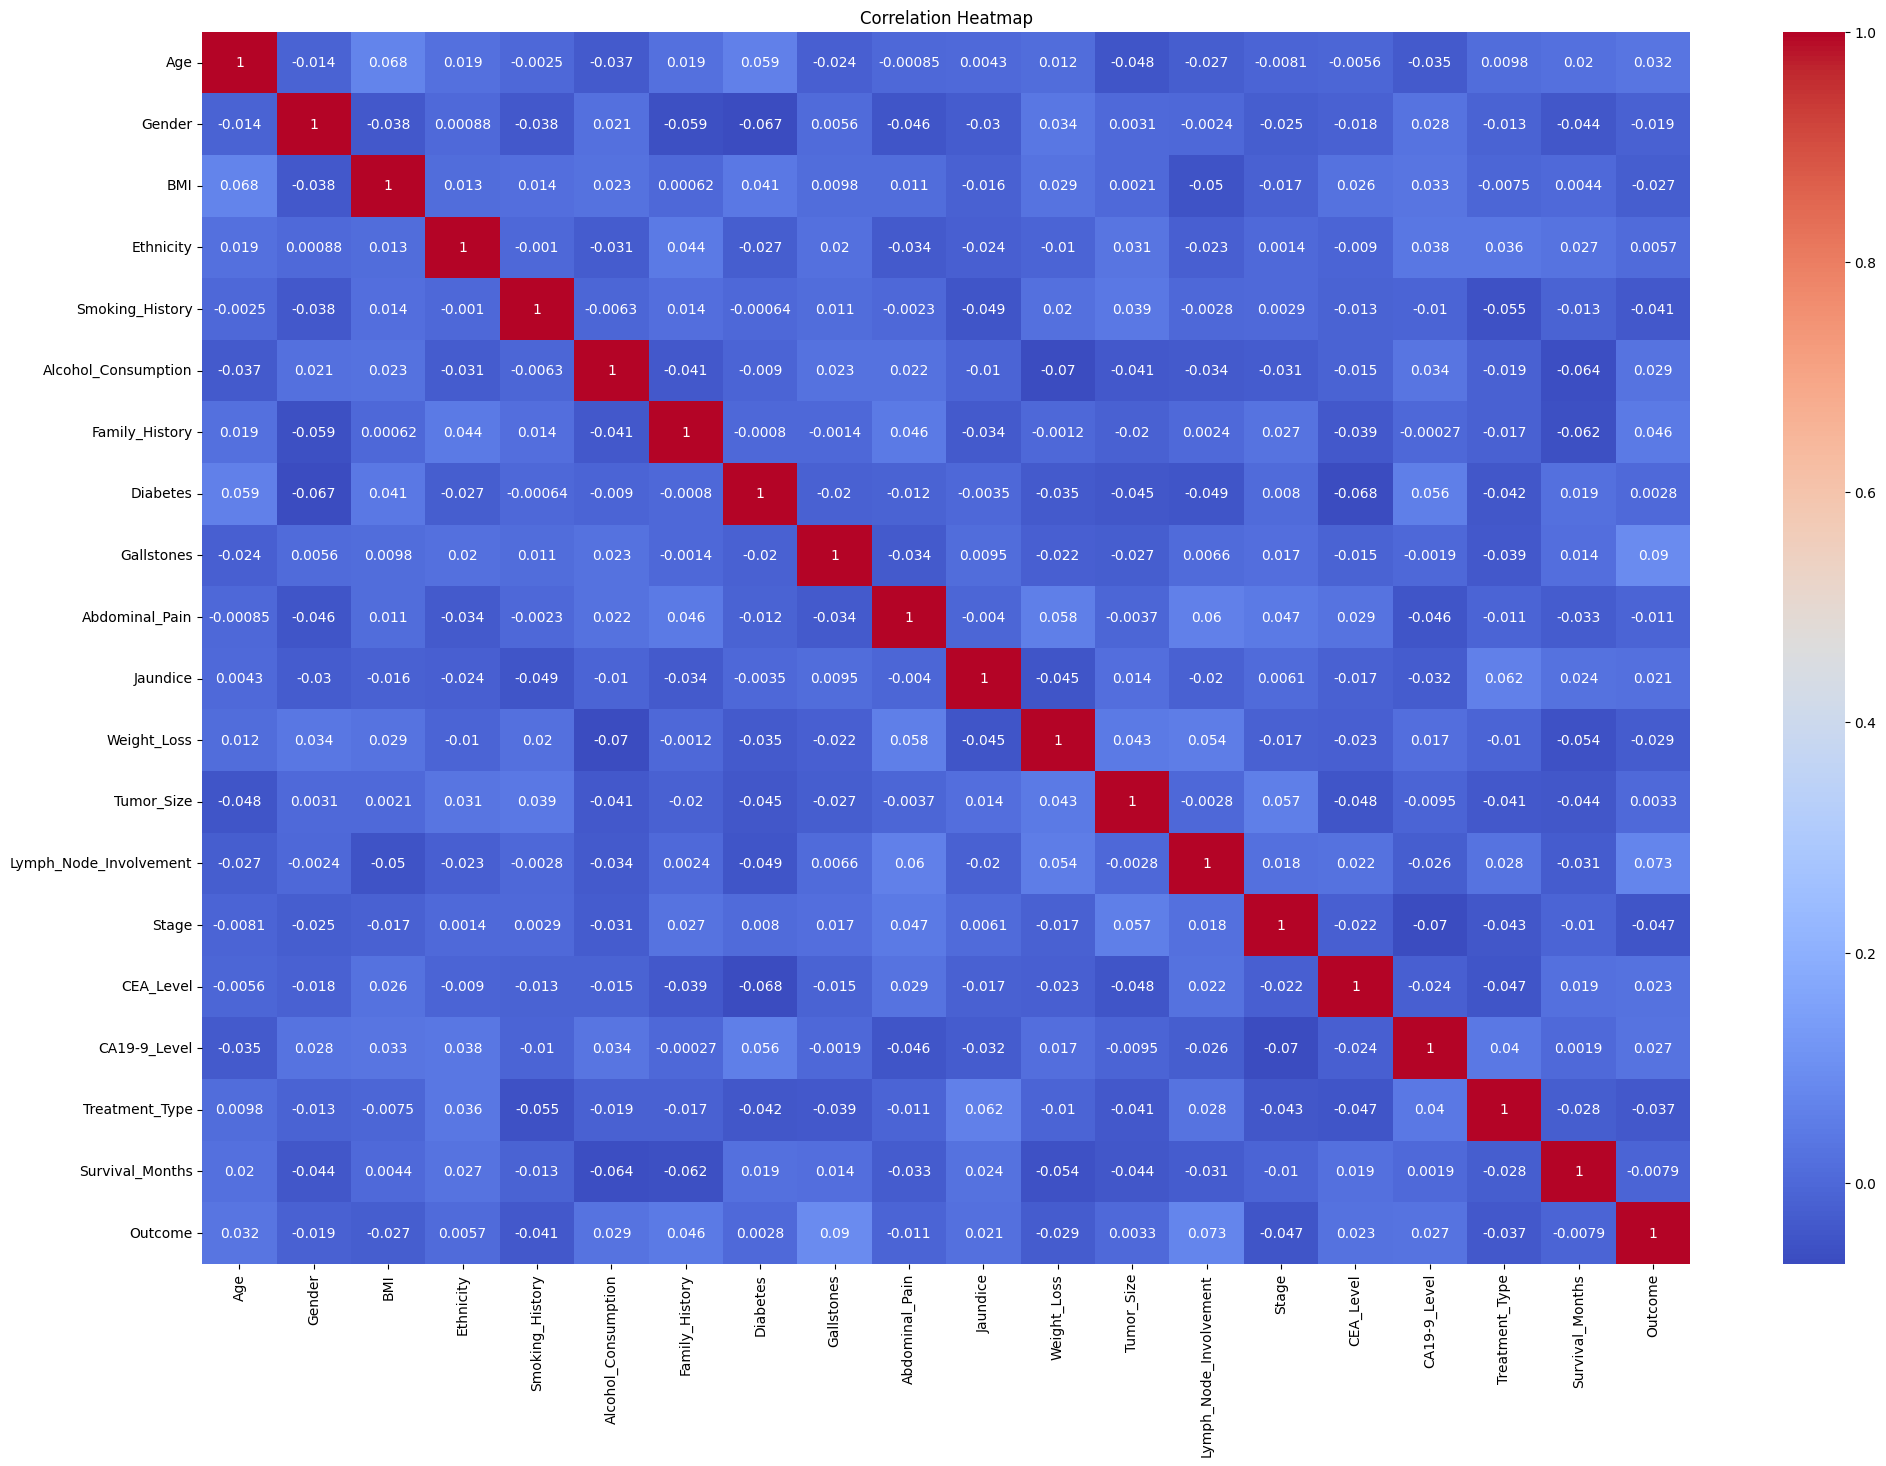

In [ ]:
# Let's first check the correlation of the parameters by drowing the heatmap

import seaborn as sns
import matplotlib.pyplot as plt

df_correlated = df.corrwith(df['Outcome'], axis=0)

# print(df_correlated.sort_values())

df.copy()
df_correlated = df.select_dtypes(include='number') #keeps only numeric columns and removes categorical (object, string, etc.)



plt.figure(figsize=(24, 16))
sns.heatmap(df_correlated.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# "Outcome" column ni chiqzib tashlab datasetni Xga assign qilamiz
# Chiqazib tashlangan "Outcome" columnni y data sifatida olamiz

X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [ ]:
# Datani scaling qilamiz
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# Datasetni train-test-splitter orqali randomli bo'laklarga bo'lib chiqamiz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training


In [ ]:
learning_rate=0.1 # hyperparameter
num_interation=100# hyperparameter
penalizer= 0 # penalizer

model = RidgeRegressor(learning_rate=learning_rate, num_interation=int(num_interation), penalizer=penalizer)
model.fit(X_train, y_train)
y_predict = model.predict(X_test)


Weights: [ 0.03153258 -0.00751162 -0.02447591 -0.00416812 -0.0186224   0.00474562
  0.02523698 -0.00788601  0.03758047 -0.00019619  0.01211849 -0.02089133
 -0.00599953  0.03840673 -0.00729135  0.01800325  0.02379225 -0.00681742
  0.00420458]
Bias: 0.5947693913410261


Predicting

In [ ]:
def mse(y_test, y_predict):
  return np.mean((y_test - y_predict)**2)

mse = mse(y_test, y_predict)
mse

rmse = np.sqrt(mse)

print(f'mse: {mse}/n')
print(f'rmse: {rmse}')

mse: 0.24795495627027875/n
rmse: 0.4979507568728847


In [ ]:
y_predict.mean()

np.float64(0.5888469579066282)

In [ ]:
y_test.mean()

np.float64(0.57)